In [1]:
!pip install pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
df = pd.read_csv("Customer Segmentation.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (10695, 12)


,Unnamed: 0,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,0,460394,Female,No,32,Yes,Healthcare,9.0,Low,3.0,Cat_6,D
1,1,461798,Female,No,56,Yes,Artist,0.0,Low,1.0,Cat_6,A
2,2,464976,Male,Yes,75,No,Lawyer,1.0,Low,1.0,Cat_4,D
3,3,462104,Male,Yes,39,No,Entertainment,9.0,Low,2.0,Cat_3,D
4,4,464829,Male,No,22,No,Healthcare,9.0,Low,5.0,Cat_4,D


In [29]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
['Unnamed: 0', 'ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation']

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10695 entries, 0 to 10694
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       10695 non-null  int64  
 1   ID               10695 non-null  int64  
 2   Gender           10695 non-null  str    
 3   Ever_Married     10505 non-null  str    
 4   Age              10695 non-null  int64  
 5   Graduated        10593 non-null  str    
 6   Profession       10533 non-null  str    
 7   Work_Experience  9597 non-null   float64
 8   Spending_Score   10695 non-null  str    
 9   Family_Size      10247 non-null  float64
 10  Var_1            10587 non-null  str    
 11  Segmentation     10695 non-null  str    
dtypes: float64(2), int64(3), str(7)
memory usage: 1002.8 KB
Non

In [30]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Unnamed: 0,ID,Age,Work_Experience,Family_Size
count,10695.000000,10695.000000,10695.000000,9597.000000,10247.000000
mean,5347.000000,463468.088640,43.511828,2.619777,2.844052
std,3087.524899,2600.966411,16.774158,3.390790,1.536427
min,0.000000,458982.000000,18.000000,0.000000,1.000000
25%,2673.500000,461220.500000,30.000000,0.000000,2.000000
50%,5347.000000,463451.000000,41.000000,1.000000,3.000000
75%,8020.500000,465733.500000,53.000000,4.000000,4.000000
max,10694.000000,467974.000000,89.000000,14.000000,9.000000


In [31]:
df = df.dropna()

print("Missing values removed.")
print("New shape:", df.shape)

Missing values removed.
New shape: (8819, 12)


In [32]:
print(df.columns.tolist())

['Unnamed: 0', 'ID', 'Gender', 'Ever_Married', 'Age', 'Graduated', 'Profession', 'Work_Experience', 'Spending_Score', 'Family_Size', 'Var_1', 'Segmentation']


In [33]:
# Select features for customer segmentation

X = df[['Age', 'Work_Experience', 'Family_Size']].copy()

print("Selected Features:")
display(X.head())

Selected Features:


,Age,Work_Experience,Family_Size
0,32,9.0,3.0
1,56,0.0,1.0
2,75,1.0,1.0
3,39,9.0,2.0
4,22,9.0,5.0


In [34]:
X = X.fillna(X.median(numeric_only=True))

print("Missing values after cleaning:")
print(X.isnull().sum())

Missing values after cleaning:
Age                0
Work_Experience    0
Family_Size        0
dtype: int64


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")

Data standardized successfully!


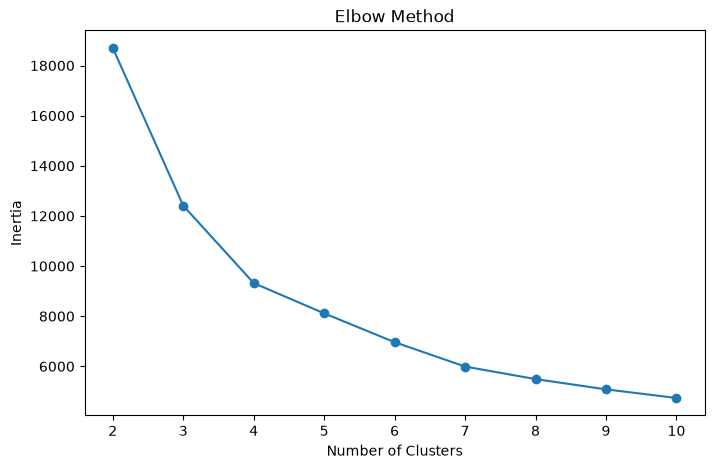

In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [37]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clusters created successfully!")
display(df.head())

Clusters created successfully!


,Unnamed: 0,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Cluster
0,0,460394,Female,No,32,Yes,Healthcare,9.0,Low,3.0,Cat_6,D,2
1,1,461798,Female,No,56,Yes,Artist,0.0,Low,1.0,Cat_6,A,0
2,2,464976,Male,Yes,75,No,Lawyer,1.0,Low,1.0,Cat_4,D,0
3,3,462104,Male,Yes,39,No,Entertainment,9.0,Low,2.0,Cat_3,D,2
4,4,464829,Male,No,22,No,Healthcare,9.0,Low,5.0,Cat_4,D,2


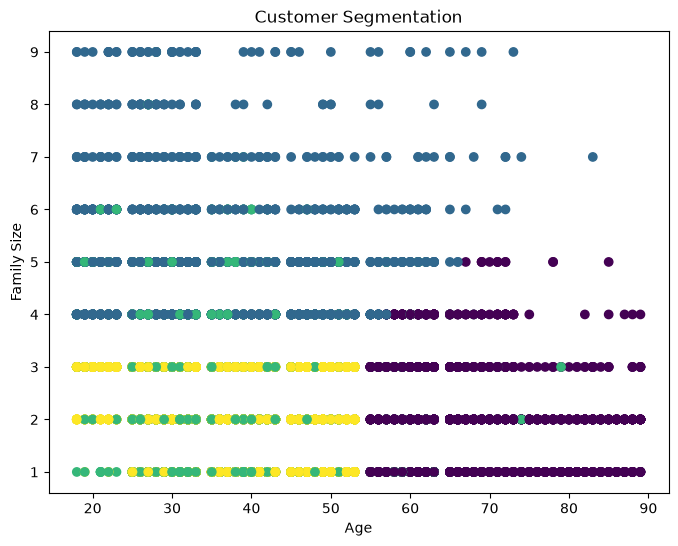

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Age'],
    df['Family_Size'],
    c=df['Cluster']
)

plt.title("Customer Segmentation")
plt.xlabel("Age")
plt.ylabel("Family Size")
plt.show()

In [39]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Work_Experience',
    'Family_Size'
]].mean()

print("Cluster Summary:")
display(cluster_summary)

Cluster Summary:


,Age,Work_Experience,Family_Size
Cluster,,,
0,68.928333,0.936667,2.101667
1,35.510698,1.285581,4.843721
2,37.366437,8.358471,2.419012
3,37.844608,0.947756,2.108171


In [40]:
df.to_csv("Customer_Segmentation_Result.csv", index=False)

print("Result saved successfully!")

Result saved successfully!


In [41]:
# Select features for customer segmentation

X = df[['Age', 'Work_Experience', 'Family_Size']].copy()

print("Selected Features:")
display(X.head())

Selected Features:


,Age,Work_Experience,Family_Size
0,32,9.0,3.0
1,56,0.0,1.0
2,75,1.0,1.0
3,39,9.0,2.0
4,22,9.0,5.0


In [42]:
# Fill missing values

X = X.fillna(X.median())

print("Missing values:")
print(X.isnull().sum())

Missing values:
Age                0
Work_Experience    0
Family_Size        0
dtype: int64


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully!")

Data scaled successfully!


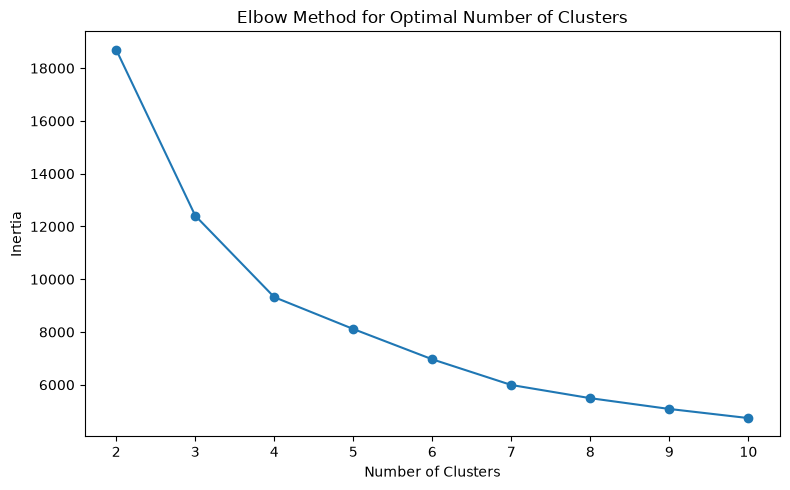

In [44]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker='o'
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

In [45]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed!")
print(df['Cluster'].value_counts())

K-Means clustering completed!
Cluster
3    2986
1    2150
2    1883
0    1800
Name: count, dtype: int64


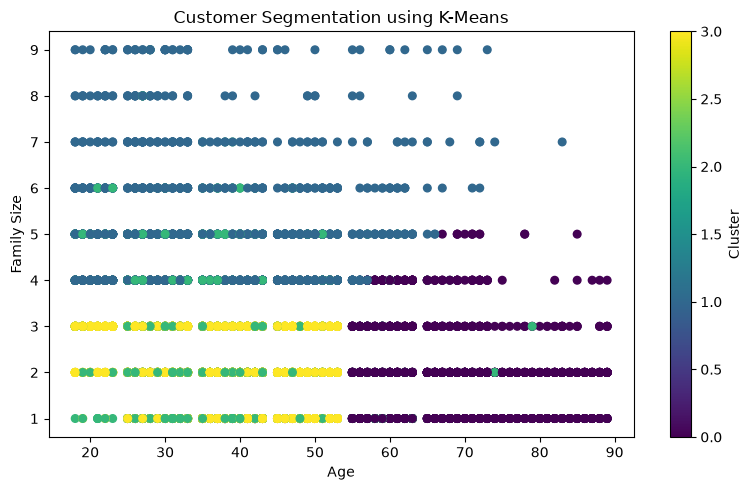

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df['Age'],
    df['Family_Size'],
    c=df['Cluster'],
    cmap='viridis',
    s=30
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Age")
plt.ylabel("Family Size")
plt.colorbar(label="Cluster")

plt.tight_layout()
plt.show()

In [47]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print("Customers in Each Cluster:")
print(cluster_counts)

Customers in Each Cluster:
Cluster
0    1800
1    2150
2    1883
3    2986
Name: count, dtype: int64


In [48]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Work_Experience', 'Family_Size']
].mean()

print("Cluster Summary:")
print(cluster_summary.round(2))

Cluster Summary:
           Age  Work_Experience  Family_Size
Cluster                                     
0        68.93             0.94         2.10
1        35.51             1.29         4.84
2        37.37             8.36         2.42
3        37.84             0.95         2.11


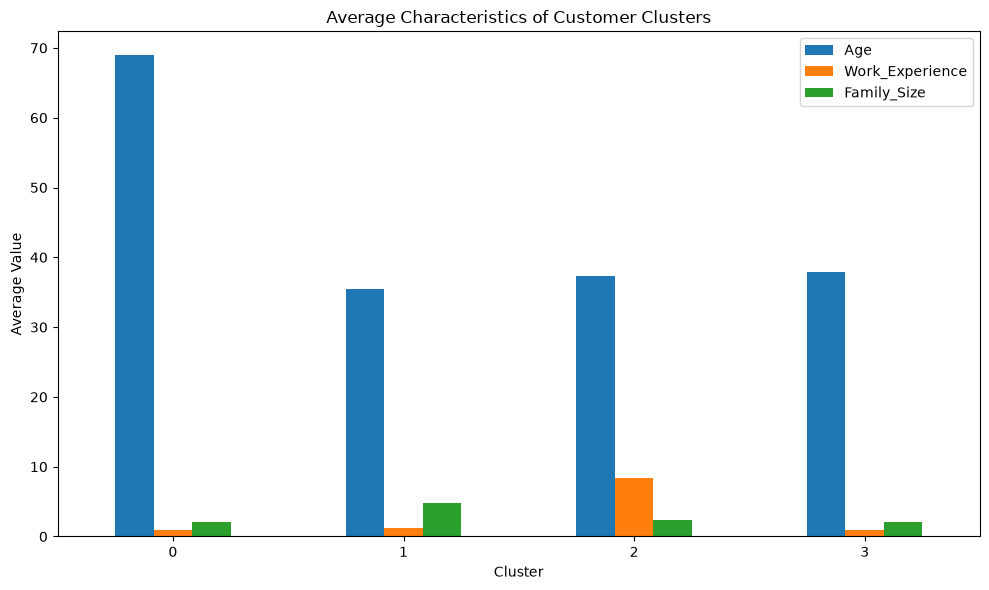

In [49]:
cluster_summary.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Average Characteristics of Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
print("Customer Segmentation Insights:")
print("1. Cluster 0 contains older customers with an average age of about 69 years.")
print("2. Cluster 1 has the largest average family size of about 4.84 members.")
print("3. Cluster 2 has the highest average work experience of about 8.36 years.")
print("4. Cluster 3 represents younger customers with low work experience and smaller families.")
print("5. K-Means successfully divided the customers into four distinct groups.")

Customer Segmentation Insights:
1. Cluster 0 contains older customers with an average age of about 69 years.
2. Cluster 1 has the largest average family size of about 4.84 members.
3. Cluster 2 has the highest average work experience of about 8.36 years.
4. Cluster 3 represents younger customers with low work experience and smaller families.
5. K-Means successfully divided the customers into four distinct groups.
